In [10]:
import re
import os
from collections import Counter
import numpy as np

In [11]:
def tokenizer(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    tokens = text.split()
    return tokens

In [12]:
def build_vocabulary(texts, max_vocab_size=5000):

    all_tokens = []
    for text in texts:
        tokens = tokenizer(text)
        all_tokens.extend(tokens)
    
    freq = Counter(all_tokens)
    most_common = freq.most_common(max_vocab_size - 2)
    
    word2idx = {'<pad>': 0, '<unk>': 1}
    idx2word = ['<pad>', '<unk>']
    
    for word, _ in most_common:
        word2idx[word] = len(idx2word)
        idx2word.append(word)
    
    return word2idx, idx2word

In [13]:
def text_to_sequence(text, word2idx, max_len=None):

    tokens = tokenizer(text)
    seq = [word2idx.get(token, 1) for token in tokens] 
    
    if max_len is not None:
        if len(seq) > max_len:
            seq = seq[:max_len]
        else:
            seq = seq + [0] * (max_len - len(seq))
    
    return seq

In [14]:
def load_rt_polarity_data(data_dir):
    texts = []
    labels = []
    
    pos_path = os.path.join(data_dir, '../data/rt-polarity.pos')
    with open(pos_path, 'r', encoding='latin-1') as f:
        pos_texts = f.readlines()
        texts.extend(pos_texts)
        labels.extend([1] * len(pos_texts))
    
    neg_path = os.path.join(data_dir, '../data/rt-polarity.neg')
    with open(neg_path, 'r', encoding='latin-1') as f:
        neg_texts = f.readlines()
        texts.extend(neg_texts)
        labels.extend([0] * len(neg_texts))
    
    return texts, labels

In [15]:
from sklearn.model_selection import train_test_split

def split_data(texts, labels, test_size=0.2, val_size=0.1, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        texts, labels, test_size=test_size + val_size, 
        stratify=labels, random_state=random_state
    )
    
    val_ratio = val_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=test_size/(test_size+val_size),
        stratify=y_temp, random_state=random_state
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test

In [16]:
def report_length_stats(texts, name):
    lengths = [len(tokenizer(text)) for text in texts]
    mean_len = np.mean(lengths)
    std_len = np.std(lengths)
    print(f"{name}: mean = {mean_len:.2f}, std = {std_len:.2f}, min = {min(lengths)}, max = {max(lengths)}")
    return mean_len, std_len

In [17]:
data_dir = './data'

texts, labels = load_rt_polarity_data(data_dir)
print(f"Total samples: {len(texts)}")
print(f"Positive: {sum(labels)}, Negative: {len(labels) - sum(labels)}")

X_train, X_val, X_test, y_train, y_val, y_test = split_data(texts, labels)

print(f"\nTraining samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

print(f"\ntraining:  pos ={sum(y_train)}, neg={len(y_train)-sum(y_train)}")
print(f"validation: pos={sum(y_val)}, neg={len(y_val)-sum(y_val)}")
print(f"test: pos={sum(y_test)}, neg={len(y_test)-sum(y_test)}")

word2idx, idx2word = build_vocabulary(X_train, max_vocab_size=5000)
print(f"\nVocabulary size: {len(word2idx)}")

print("\nSequence length statistics ")
report_length_stats(X_train, "Training")
report_length_stats(X_val, "Validation")
report_length_stats(X_test, "Test")

Total samples: 10662
Positive: 5331, Negative: 5331

Training samples: 7463
Validation samples: 1066
Test samples: 2133

training:  pos =3732, neg=3731
validation: pos=533, neg=533
test: pos=1066, neg=1067

Vocabulary size: 5000

Sequence length statistics 
Training: mean = 18.61, std = 8.61, min = 1, max = 51
Validation: mean = 18.34, std = 8.81, min = 1, max = 44
Test: mean = 18.20, std = 8.40, min = 1, max = 48


(np.float64(18.204406938584153), np.float64(8.39962042806537))

### Part 2


In [18]:
import torch
from torch.utils.data import Dataset, DataLoader

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=None):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        sequence = text_to_sequence(text, self.word2idx, max_len=self.max_len)
        return torch.tensor(sequence, dtype=torch.long), torch.tensor(label, dtype=torch.float32)

In [19]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

def dynamic_padding_collate(batch):

    sequences, labels = zip(*batch)    
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=0)
    return padded_sequences, torch.tensor(labels, dtype=torch.float32), lengths

In [20]:
class VanillaRNN(torch.nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=1):
        super(VanillaRNN, self).__init__()
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = torch.nn.RNN(embedding_dim, hidden_dim, num_layers, batch_first=True, nonlinearity='tanh')
        self.fc = torch.nn.Linear(hidden_dim, 1)
        self.sigmoid = torch.nn.Sigmoid()
    
    def forward(self, x, lengths):
        embedded = self.embedding(x) 
        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, hidden = self.rnn(packed_embedded)
        last_hidden = hidden[-1]
        output = self.fc(last_hidden)
        output = self.sigmoid(output).squeeze()
        return output

In [21]:
class LSTMModel(torch.nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=1):
        super(LSTMModel, self).__init__()
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = torch.nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim * 2, 1) 
        self.sigmoid = torch.nn.Sigmoid()
    
    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        last_hidden = hidden[-1]
        last_cell = cell[-1]
        combined = torch.cat((last_hidden, last_cell), dim=1)
        output = self.fc(combined)
        output = self.sigmoid(output).squeeze()
        return output

In [22]:
class GRUModel(torch.nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=1):
        super(GRUModel, self).__init__()
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = torch.nn.GRU(embedding_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim, 1)
        self.sigmoid = torch.nn.Sigmoid()
    
    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, hidden = self.gru(packed_embedded)
        last_hidden = hidden[-1]
        output = self.fc(last_hidden)
        output = self.sigmoid(output).squeeze()
        return output

In [23]:
def create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, word2idx, batch_size=32, max_len=None):
    train_dataset = SentimentDataset(X_train, y_train, word2idx, max_len)
    val_dataset = SentimentDataset(X_val, y_val, word2idx, max_len)
    test_dataset = SentimentDataset(X_test, y_test, word2idx, max_len)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=dynamic_padding_collate)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=dynamic_padding_collate)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=dynamic_padding_collate)
    
    return train_loader, val_loader, test_loader

In [24]:
def test_models():
    vocab_size = 5000
    batch_size = 4
    seq_len = 10
    
    dummy_x = torch.randint(0, vocab_size, (batch_size, seq_len))
    dummy_lengths = torch.tensor([10, 8, 6, 5])
    
    rnn_model = VanillaRNN(vocab_size)
    rnn_model.eval()
    with torch.no_grad():
        out_rnn = rnn_model(dummy_x, dummy_lengths)
    print(f"Vanilla RNN output shape: {out_rnn.shape}")
    
    lstm_model = LSTMModel(vocab_size)
    lstm_model.eval()
    with torch.no_grad():
        out_lstm = lstm_model(dummy_x, dummy_lengths)
    print(f"LSTM output shape: {out_lstm.shape}")
    
    gru_model = GRUModel(vocab_size)
    gru_model.eval()
    with torch.no_grad():
        out_gru = gru_model(dummy_x, dummy_lengths)
    print(f"GRU output shape: {out_gru.shape}")
    

test_models()

Vanilla RNN output shape: torch.Size([4])
LSTM output shape: torch.Size([4])
GRU output shape: torch.Size([4])


In [25]:
# Cell 9: Create actual dataloaders (run after preprocessing from subsection 1)
# Uncomment and run after executing subsection 1 cells

batch_size = 32
train_loader, val_loader, test_loader = create_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test, 
    word2idx, batch_size=batch_size, max_len=None
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

# Inspect one batch
for batch_x, batch_y, batch_lengths in train_loader:
    print(f"\nBatch input shape: {batch_x.shape}")
    print(f"Batch labels shape: {batch_y.shape}")
    print(f"Batch lengths: {batch_lengths}")
    break

Number of training batches: 234
Number of validation batches: 34
Number of test batches: 67

Batch input shape: torch.Size([32, 31])
Batch labels shape: torch.Size([32])
Batch lengths: tensor([14, 20, 15, 16, 18, 29,  3, 28, 25, 19, 11, 19,  1, 21, 16, 12, 22,  7,
        15, 23, 10,  6, 10, 19, 18, 21, 25, 31, 12,  8, 15, 21])


### Part 3

In [26]:
import time
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, device='cpu'):
    model = model.to(device)
    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_x, batch_y, lengths in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            lengths = lengths.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x, lengths)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_x.size(0)
            preds = (outputs >= 0.5).float()
            train_correct += (preds == batch_y).sum().item()
            train_total += batch_y.size(0)
        
        train_loss = train_loss / train_total
        train_acc = train_correct / train_total
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch_x, batch_y, lengths in val_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)
                lengths = lengths.to(device)
                
                outputs = model(batch_x, lengths)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item() * batch_x.size(0)
                preds = (outputs >= 0.5).float()
                val_correct += (preds == batch_y).sum().item()
                val_total += batch_y.size(0)
        
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    training_time = time.time() - start_time
    
    return history, training_time

In [27]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [28]:
def evaluate_model(model, test_loader, device='cpu'):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_x, batch_y, lengths in test_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            lengths = lengths.to(device)
            
            outputs = model(batch_x, lengths)
            preds = (outputs >= 0.5).float()
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
    
    return correct / total

In [ ]:
def train_all_models(train_loader, val_loader, test_loader, vocab_size, epochs=10, lr=0.001, device='cpu'):

    results = {}
    
    models = {
        'Vanilla RNN': VanillaRNN(vocab_size),
        'LSTM': LSTMModel(vocab_size),
        'GRU': GRUModel(vocab_size)
    }
    
    for name, model in models.items():
        print(f"Training {name}")
        print(f"Trainable parameters: {count_parameters(model):,}")
        
        history, training_time = train_model(model, train_loader, val_loader, epochs, lr, device)
        test_acc = evaluate_model(model, test_loader, device)
        
        results[name] = {
            'model': model,
            'history': history,
            'training_time': training_time,
            'num_params': count_parameters(model),
            'test_acc': test_acc,
            'val_acc': history['val_acc'][-1]
        }
        
        print(f"\n{name} completed in {training_time:.2f} seconds")
        print(f"Final validation accuracy: {results[name]['val_acc']:.4f}")
        print(f"Test accuracy: {test_acc:.4f}")
    
    return results

In [33]:
def plot_learning_curves(results,):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = {'Vanilla RNN': 'blue', 'LSTM': 'green', 'GRU': 'red'}
    linestyles = {'train': '-', 'val': '--'}
    
    for name, data in results.items():
        history = data['history']
        epochs = range(1, len(history['train_loss']) + 1)
        ax1.plot(epochs, history['train_loss'], color=colors[name], linestyle='-', 
                label=f'{name} (train)')
        ax1.plot(epochs, history['val_loss'], color=colors[name], linestyle='--', 
                label=f'{name} (val)')
    
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    for name, data in results.items():
        history = data['history']
        epochs = range(1, len(history['train_acc']) + 1)
        ax2.plot(epochs, history['train_acc'], color=colors[name], linestyle='-', 
                label=f'{name} (train)')
        ax2.plot(epochs, history['val_acc'], color=colors[name], linestyle='--', 
                label=f'{name} (val)')
    
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [63]:
def print_results_table(results):

    print(f"{'Model':<15} {'Parameters':<15} {'Train Time (s)':<18} {'Val Acc':<12} {'Test Acc':<12}")
    print("-"*80)
    
    for name, data in results.items():
        print(f"{name:<15} {data['num_params']:<15,} {data['training_time']:<18.2f} {data['val_acc']:<12.4f} {data['test_acc']:<12.4f}")
    

In [78]:
device = 'cpu' if torch.mps.is_available() else 'cpu'
print(f"Using device: {device}")

vocab_size = len(word2idx)
print(f"Vocabulary size: {vocab_size}")

results = train_all_models(
    train_loader, val_loader, test_loader, 
    vocab_size, epochs=20, lr=0.001, device=device
)

Using device: cpu
Vocabulary size: 5000

Training Vanilla RNN
Trainable parameters: 344,961
Epoch 1/20 | Train Loss: 0.6920 | Train Acc: 0.5401 | Val Loss: 0.6792 | Val Acc: 0.5741
Epoch 2/20 | Train Loss: 0.6524 | Train Acc: 0.6172 | Val Loss: 0.6633 | Val Acc: 0.5947
Epoch 3/20 | Train Loss: 0.5989 | Train Acc: 0.6861 | Val Loss: 0.6569 | Val Acc: 0.6295
Epoch 4/20 | Train Loss: 0.5425 | Train Acc: 0.7277 | Val Loss: 0.6461 | Val Acc: 0.6567
Epoch 5/20 | Train Loss: 0.4687 | Train Acc: 0.7865 | Val Loss: 0.6658 | Val Acc: 0.6595
Epoch 6/20 | Train Loss: 0.3977 | Train Acc: 0.8263 | Val Loss: 0.6966 | Val Acc: 0.6839
Epoch 7/20 | Train Loss: 0.3283 | Train Acc: 0.8664 | Val Loss: 0.8001 | Val Acc: 0.6623
Epoch 8/20 | Train Loss: 0.2687 | Train Acc: 0.8941 | Val Loss: 0.8147 | Val Acc: 0.6839
Epoch 9/20 | Train Loss: 0.2030 | Train Acc: 0.9244 | Val Loss: 0.8914 | Val Acc: 0.6867
Epoch 10/20 | Train Loss: 0.1490 | Train Acc: 0.9465 | Val Loss: 1.0570 | Val Acc: 0.6820
Epoch 11/20 | Tra

KeyboardInterrupt: 

Model           Parameters      Train Time (s)     Val Acc      Test Acc    
--------------------------------------------------------------------------------
Vanilla RNN     344,961         28.28              0.6651       0.6995      
LSTM            419,585         53.46              0.7083       0.7075      
GRU             394,625         45.08              0.7205       0.7281      


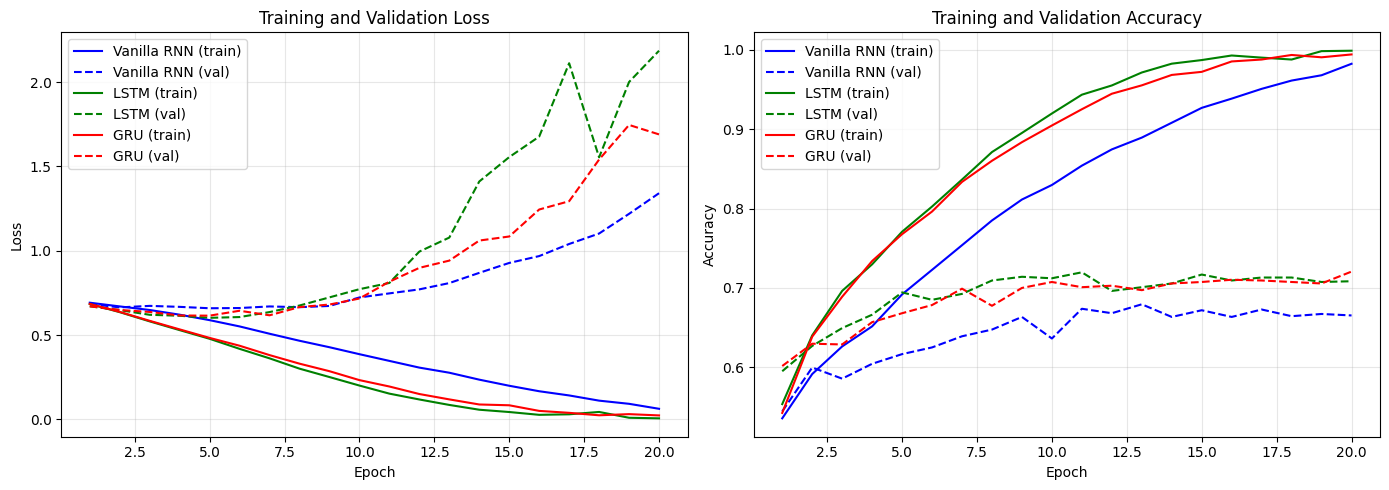

In [ ]:
print_results_table(results)
plot_learning_curves(results)

#### Part 4

In [ ]:
def extract_long_samples(val_loader, min_len=30, max_samples=32):

    all_sequences = []
    all_labels = []
    
    for batch_x, batch_y, lengths in val_loader:
        for i in range(len(lengths)):
            if lengths[i] >= min_len and len(all_sequences) < max_samples:
                seq = batch_x[i][:30]
                all_sequences.append(seq)
                all_labels.append(batch_y[i])
        
        if len(all_sequences) >= max_samples:
            break
    
    batch_x = torch.stack(all_sequences[:max_samples])
    batch_y = torch.tensor(all_labels[:max_samples], dtype=torch.float32)
    lengths = torch.tensor([30] * len(batch_x), dtype=torch.long)
    
    print(f"Extracted {len(batch_x)} samples, each with {lengths[0]} tokens")
    return batch_x, batch_y, lengths

In [ ]:
def diagnostic_gradient(model, batch_x, batch_y, lengths, device='cpu'):
 
    model = model.to(device)
    model.eval()
    
    batch_x = batch_x.to(device)
    batch_y = batch_y.to(device)
    lengths = lengths.to(device)
    
    T = batch_x.shape[1]
    sensitivities = []
    
    with torch.no_grad():
        baseline_outputs = model(batch_x, lengths)
        baseline_loss = torch.nn.BCELoss()(baseline_outputs, batch_y).item()
    
    for t in range(T):
        x_perturbed = batch_x.clone()
        x_perturbed[:, t] = 1  # Replace with <unk> token
        
        with torch.no_grad():
            perturbed_outputs = model(x_perturbed, lengths)
            perturbed_loss = torch.nn.BCELoss()(perturbed_outputs, batch_y).item()
        
        sensitivity = abs(perturbed_loss - baseline_loss)
        sensitivities.append(sensitivity)
    
    return np.array(sensitivities)

In [ ]:
def run_gradient_diagnostics(models, batch_x, batch_y, lengths, device='cpu'):

    results = {}
    
    for name, model in models.items():
        if name in ['Vanilla RNN', 'LSTM']:
            print(f"\nAnalyzing {name}")
            try:
                sensitivities = diagnostic_gradient(model, batch_x, batch_y, lengths, device)
                results[name] = sensitivities
                print(f"  Sensitivity range: [{sensitivities.min():.6f}, {sensitivities.max():.6f}]")
                print(f"  Sensitivity at t=0 (early): {sensitivities[0]:.6f}")
                print(f"  Sensitivity at t=29 (late): {sensitivities[-1]:.6f}")
                print(f"  Ratio early/late: {sensitivities[0]/sensitivities[-1]:.4f}")
                print(results[name])
            except Exception as e:
                print(f"  Error: {e}")
                results[name] = None
    
    return results

In [ ]:
def plot_gradient_flow(grad_results):

    plt.figure(figsize=(12, 6))
    time_steps = range(1, 31)
    colors = {'Vanilla RNN': 'blue', 'LSTM': 'green'}
    markers = {'Vanilla RNN': 'o', 'LSTM': 's'}
    
    for name, sensitivities in grad_results.items():
        if sensitivities is not None and len(sensitivities) > 0:
            plt.plot(time_steps[:len(sensitivities)], sensitivities, 
                    color=colors[name], marker=markers[name], 
                    markersize=3, linewidth=2, label=name, alpha=0.7)
    
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Loss Sensitivity (change in loss when token at t is perturbed)', fontsize=12)
    plt.title('Gradient Flow Through Time: Vanilla RNN vs LSTM', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    all_vals = [v for v in grad_results.values() if v is not None]
    if all_vals and len(all_vals) > 0:
        max_val = max([v.max() for v in all_vals if len(v) > 0])
        min_val = min([v.min() for v in all_vals if len(v) > 0])
        if max_val / (min_val + 1e-8) > 100:
            plt.yscale('log')
            plt.ylabel('Loss Sensitivity (log scale)', fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def run_full_gradient_analysis(results, val_loader, device='cpu'):
    
    print("GRADIENT DIAGNOSTICS & BPTT ANALYSIS")
    
    batch_x, batch_y, lengths = extract_long_samples(val_loader, min_len=30, max_samples=32)
    trained_models = {
        'Vanilla RNN': results['Vanilla RNN']['model'],
        'LSTM': results['LSTM']['model']
    }
    grad_results = run_gradient_diagnostics(trained_models, batch_x, batch_y, lengths, device)
    plot_gradient_flow(grad_results)
    
    print("\n GRADIENT VANISHING ANALYSIS:")
    
    for name, sensitivities in grad_results.items():
        if sensitivities is not None and len(sensitivities) >= 30:
            early = sensitivities[0]
            late = sensitivities[-1]
            ratio = early / (late + 1e-8)
            
            print(f"\n{name}:")
            print(f"  Early timestep sensitivity (t=1): {early:.6f}")
            print(f"  Late timestep sensitivity (t=30): {late:.6f}")
            print(f"  Ratio (t=1 on t=30): {ratio:.4f}")
    
    return grad_results

GRADIENT DIAGNOSTICS & BPTT ANALYSIS
Extracted 32 samples, each with 30 tokens

Analyzing Vanilla RNN
  Sensitivity range: [0.000168, 0.533051]
  Sensitivity at t=0 (early): 0.013326
  Sensitivity at t=29 (late): 0.021811
  Ratio early/late: 0.6109
[1.33255720e-02 4.12710905e-02 1.31795406e-01 2.86883950e-01
 6.70386553e-02 5.17940521e-02 1.68085098e-04 1.29023433e-01
 2.53854156e-01 2.33948231e-03 1.02092862e-01 1.52034760e-02
 5.64491749e-03 1.29070044e-01 9.37777758e-02 2.89571285e-02
 1.38662934e-01 9.44211483e-02 1.47797108e-01 1.38435364e-02
 7.54362345e-02 2.82968283e-02 9.85292196e-02 1.49863601e-01
 1.25651598e-01 2.99662471e-01 1.92194104e-01 1.91464186e-01
 5.33051372e-01 2.18113661e-02]

Analyzing LSTM
  Sensitivity range: [0.003965, 0.717799]
  Sensitivity at t=0 (early): 0.132294
  Sensitivity at t=29 (late): 0.717799
  Ratio early/late: 0.1843
[0.13229394 0.03812504 0.04138398 0.02893138 0.00396538 0.23984265
 0.04238105 0.09838533 0.03398919 0.07298446 0.02231479 0.0270

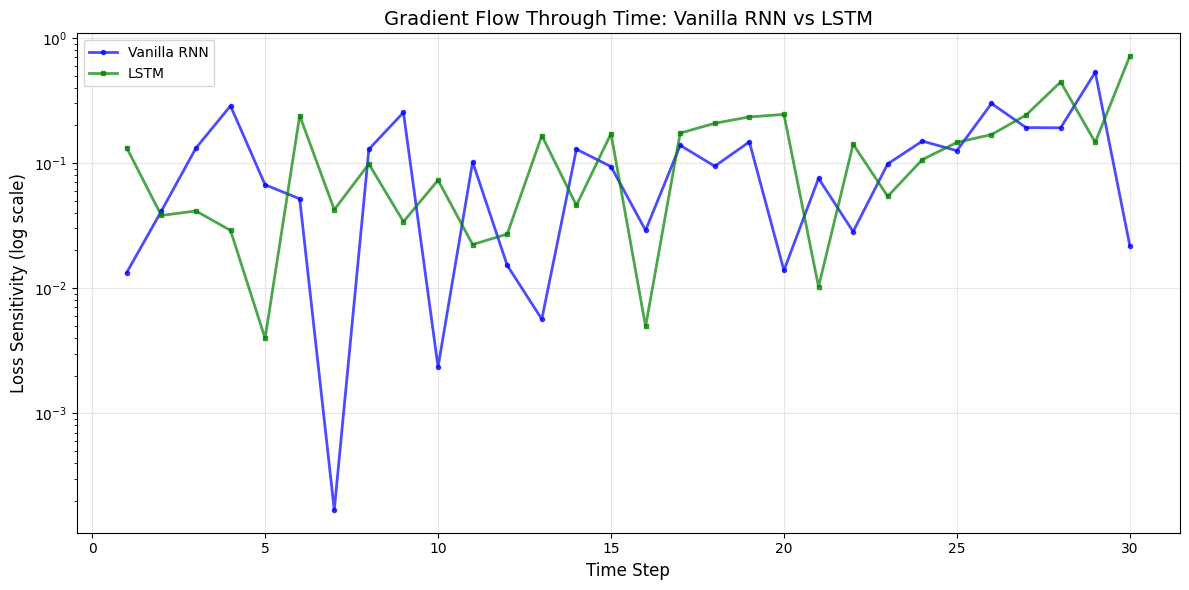


 GRADIENT VANISHING ANALYSIS:

Vanilla RNN:
  Early timestep sensitivity (t=1): 0.013326
  Late timestep sensitivity (t=30): 0.021811
  Ratio (t=1 on t=30): 0.6109

LSTM:
  Early timestep sensitivity (t=1): 0.132294
  Late timestep sensitivity (t=30): 0.717799
  Ratio (t=1 on t=30): 0.1843


In [ ]:
grad_results = run_full_gradient_analysis(results, val_loader, device=device)